# Tarea 04: Prediccion de precios de NVIDIA y comparacion CPU vs GPU

En este notebook se utiliza el dataset local `NVIDIA_Stock_Prices.csv` para realizar analisis exploratorio, preparar una serie temporal y entrenar tres modelos con TensorFlow para predecir el precio de cierre de NVIDIA. Adicionalmente, se mide el tiempo de entrenamiento y el desempeno de los modelos en CPU y GPU cuando la GPU esta disponible.

## Dependencias y ejecucion local

La lectura del dataset se realiza de forma local desde `../data/NVIDIA_Stock_Prices.csv`; no se utiliza Colab ni rutas externas.

Dependencias recomendadas para esta tarea:

```bash
pandas>=2.2.0
numpy>=1.26.0
matplotlib>=3.8.0
seaborn>=0.13.0
scikit-learn>=1.5.0
jupyterlab>=4.0.0
ipykernel>=6.29.0
tensorflow[and-cuda]>=2.21.0,<3.0.0
```

Instalacion con `pip`:

```bash
cd tarea_04_cpu_vs_gpu
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
python -m ipykernel install --user --name tarea-04-cpu-vs-gpu --display-name "Tarea 04 CPU vs GPU"
jupyter lab
```

Instalacion equivalente con Poetry:

```bash
cd tarea_04_cpu_vs_gpu
poetry init --no-interaction --name tarea-04-cpu-vs-gpu --python ">=3.12,<3.13"
poetry add pandas numpy matplotlib seaborn scikit-learn jupyterlab ipykernel "tensorflow[and-cuda]>=2.21,<3"
poetry run python -m ipykernel install --user --name tarea-04-cpu-vs-gpu --display-name "Tarea 04 CPU vs GPU"
poetry run jupyter lab
```

Para GPU se necesita que el driver NVIDIA funcione en el sistema. Se puede verificar con:

```bash
nvidia-smi
```

`tensorflow[and-cuda]` instala las librerias CUDA de Python que TensorFlow necesita. CUDA Toolkit 12.5 puede estar instalado en el sistema, pero para este ejercicio lo mas importante es que el driver NVIDIA este activo y que TensorFlow detecte la GPU.

## 1. Carga de librerias

In [2]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 2. Configuracion general

In [3]:
DATA_PATH = Path("../data/NVIDIA_Stock_Prices.csv")

RANDOM_STATE = 2927
WINDOW_SIZE = 30
TEST_SIZE = 0.20
EPOCHS = 20
BATCH_SIZE = 64

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

## 3. Verificacion de TensorFlow, CPU y GPU

In [4]:
print("TensorFlow:", tf.__version__)
print("Dispositivos fisicos:", tf.config.list_physical_devices())

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detectadas: {gpus}")
    except RuntimeError as error:
        print("No se pudo configurar memory growth porque TensorFlow ya inicializo la GPU:")
        print(error)
else:
    print("No se detecto GPU. El notebook ejecutara solamente CPU.")

TensorFlow: 2.21.0
Dispositivos fisicos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Carga local del dataset

In [5]:
datos = pd.read_csv(DATA_PATH, skiprows=14)

datos["date"] = pd.to_datetime(datos["date"])
columnas_numericas = ["open", "high", "low", "close", "volume"]
datos[columnas_numericas] = datos[columnas_numericas].apply(pd.to_numeric, errors="coerce")

datos = datos.sort_values("date").reset_index(drop=True)
datos.head()

,date,open,high,low,close,volume
0,1899-12-31,0.0322,0.0329,0.0313,0.0329,159146
1,1999-01-22,0.0401,0.0448,0.0356,0.0376,5186596
2,1999-01-25,0.0405,0.0420,0.0376,0.0415,974288
3,1999-01-26,0.0420,0.0428,0.0377,0.0383,655131
4,1999-01-27,0.0385,0.0394,0.0363,0.0382,466929


## 5. Analisis exploratorio

In [6]:
print(f"Filas: {datos.shape[0]}")
print(f"Columnas: {datos.shape[1]}")
print(f"Fecha inicial: {datos['date'].min().date()}")
print(f"Fecha final: {datos['date'].max().date()}")
print("\nValores faltantes por columna:")
print(datos.isna().sum())

Filas: 6876
Columnas: 6
Fecha inicial: 1899-12-31
Fecha final: 2026-05-22

Valores faltantes por columna:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [7]:
datos.describe().T

,count,mean,min,25%,50%,75%,max,std
date,6876,2012-09-14 23:33:24.188481,1899-12-31 00:00:00,2005-11-20 06:00:00,2012-09-18 12:00:00,2019-07-22 06:00:00,2026-05-22 00:00:00,NaN
open,6876.0,16.100398,0.0319,0.2647,0.4551,6.001775,229.87,41.23178
high,6876.0,16.366257,0.0325,0.2724,0.46305,6.092025,236.54,41.858382
low,6876.0,15.808668,0.0306,0.2574,0.4486,5.897225,229.3,40.525568
close,6876.0,16.098968,0.0313,0.265175,0.45535,5.989875,235.74,41.213555
volume,6876.0,29785825.3153,37569.0,5886604.75,10281497.0,19820247.75,818562650.0,62328066.380645


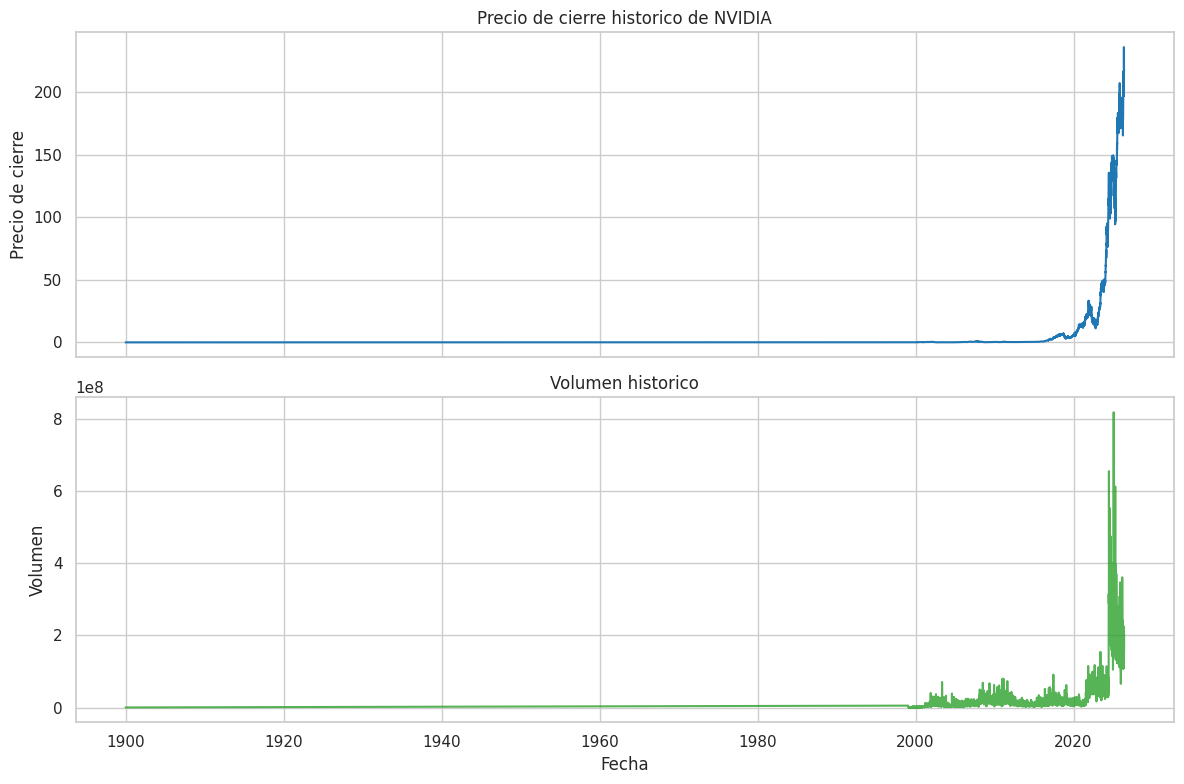

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(datos["date"], datos["close"], color="tab:blue")
axes[0].set_title("Precio de cierre historico de NVIDIA")
axes[0].set_ylabel("Precio de cierre")

axes[1].plot(datos["date"], datos["volume"], color="tab:green", alpha=0.8)
axes[1].set_title("Volumen historico")
axes[1].set_ylabel("Volumen")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

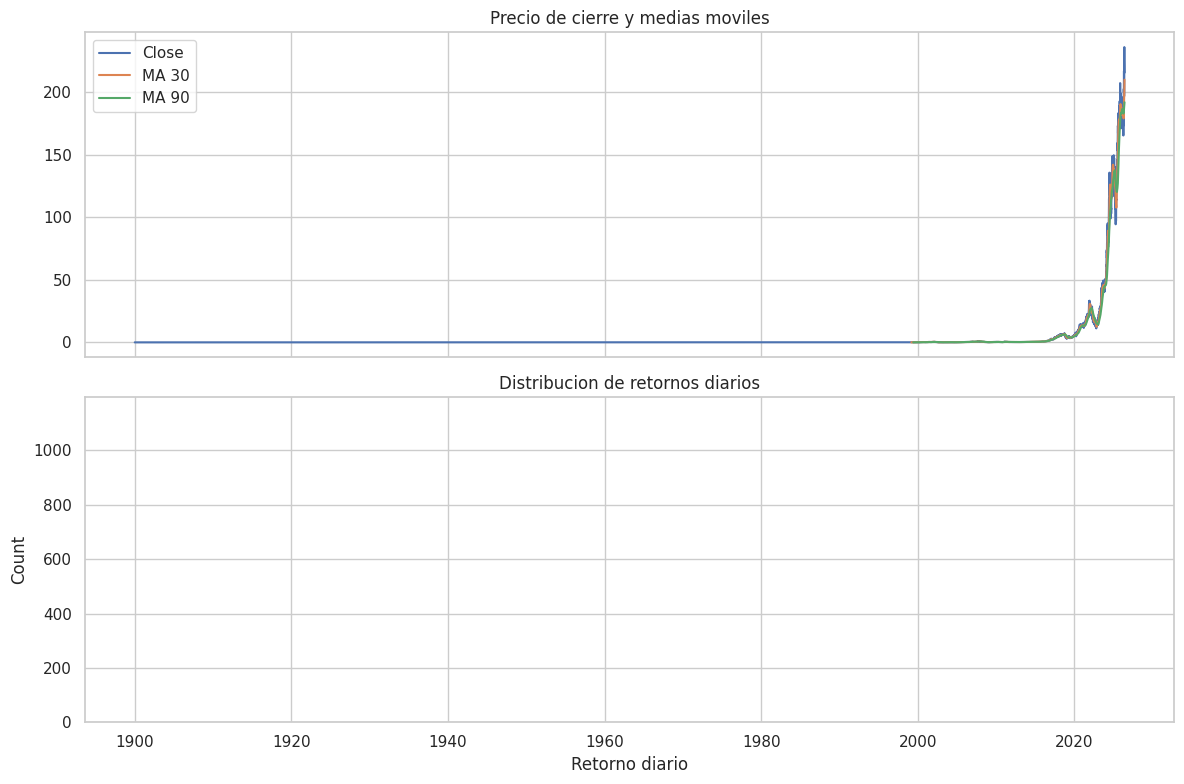

In [9]:
datos_eda = datos.copy()
datos_eda["daily_return"] = datos_eda["close"].pct_change()
datos_eda["close_ma_30"] = datos_eda["close"].rolling(30).mean()
datos_eda["close_ma_90"] = datos_eda["close"].rolling(90).mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(datos_eda["date"], datos_eda["close"], label="Close")
axes[0].plot(datos_eda["date"], datos_eda["close_ma_30"], label="MA 30")
axes[0].plot(datos_eda["date"], datos_eda["close_ma_90"], label="MA 90")
axes[0].set_title("Precio de cierre y medias moviles")
axes[0].legend()

sns.histplot(datos_eda["daily_return"].dropna(), bins=80, ax=axes[1], color="tab:purple")
axes[1].set_title("Distribucion de retornos diarios")
axes[1].set_xlabel("Retorno diario")

plt.tight_layout()
plt.show()

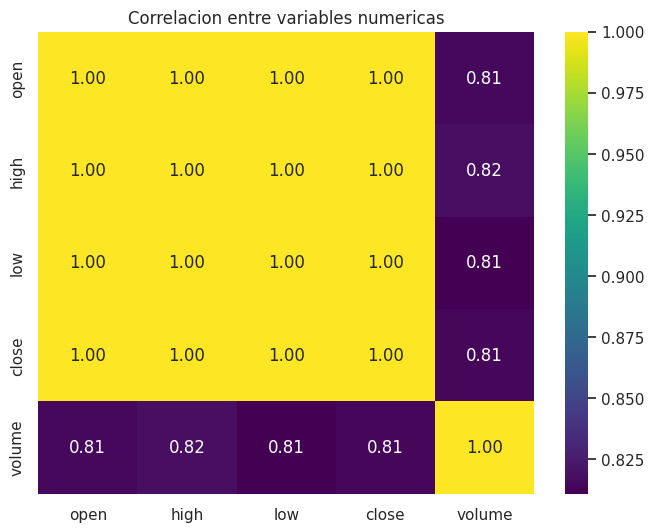

In [10]:
matriz_correlacion = datos[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlacion entre variables numericas")
plt.show()

## 6. Preparacion de datos para prediccion

El objetivo sera predecir el precio de cierre del siguiente dia usando una ventana temporal de los ultimos `WINDOW_SIZE` dias. Se usan variables de precio, volumen y algunos indicadores simples derivados de la serie.

In [11]:
datos_modelo = datos.copy()
datos_modelo["daily_return"] = datos_modelo["close"].pct_change()
datos_modelo["range_pct"] = (datos_modelo["high"] - datos_modelo["low"]) / datos_modelo["close"]
datos_modelo["close_ma_5"] = datos_modelo["close"].rolling(5).mean()
datos_modelo["close_ma_20"] = datos_modelo["close"].rolling(20).mean()
datos_modelo["volume_ma_5"] = datos_modelo["volume"].rolling(5).mean()
datos_modelo["target_close_next_day"] = datos_modelo["close"].shift(-1)

datos_modelo = datos_modelo.dropna().reset_index(drop=True)

feature_cols = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "daily_return",
    "range_pct",
    "close_ma_5",
    "close_ma_20",
    "volume_ma_5",
]
target_col = "target_close_next_day"

datos_modelo[["date"] + feature_cols + [target_col]].head()

,date,open,high,low,close,volume,daily_return,range_pct,close_ma_5,close_ma_20,volume_ma_5,target_close_next_day
0,1999-02-18,0.0392,0.0397,0.0375,0.0386,135215,0.015789,0.056995,0.03886,0.037205,225947.0,0.0399
1,1999-02-19,0.0382,0.0406,0.0377,0.0399,144007,0.033679,0.072682,0.03930,0.037555,204268.0,0.0401
2,1999-02-22,0.0406,0.0411,0.0379,0.0401,391926,0.005013,0.079800,0.03934,0.037680,240717.0,0.0420
3,1999-02-23,0.0410,0.0428,0.0387,0.0420,263542,0.047382,0.097619,0.03972,0.037705,212840.4,0.0454
4,1999-02-24,0.0482,0.0502,0.0443,0.0454,1170861,0.080952,0.129956,0.04120,0.038060,421110.2,0.0439


In [12]:
split_index = int(len(datos_modelo) * (1 - TEST_SIZE))

train_df = datos_modelo.iloc[:split_index].copy()
test_df = datos_modelo.iloc[split_index:].copy()

feature_scaler = StandardScaler()
target_scaler = MinMaxScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[feature_cols])
test_features_scaled = feature_scaler.transform(test_df[feature_cols])

train_target_scaled = target_scaler.fit_transform(train_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

print(f"Observaciones de entrenamiento: {len(train_df)}")
print(f"Observaciones de prueba: {len(test_df)}")

Observaciones de entrenamiento: 5484
Observaciones de prueba: 1372


In [13]:
def crear_ventanas(features, target, window_size):
    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y).reshape(-1, 1)


X_train, y_train = crear_ventanas(train_features_scaled, train_target_scaled, WINDOW_SIZE)
X_test, y_test = crear_ventanas(test_features_scaled, test_target_scaled, WINDOW_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5454, 30, 10)
y_train: (5454, 1)
X_test: (1342, 30, 10)
y_test: (1342, 1)


## 7. Definicion de los tres algoritmos/modelos

In [14]:
input_shape = (X_train.shape[1], X_train.shape[2])


def construir_mlp():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1),
    ])


def construir_lstm():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ])


def construir_gru():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ])


constructores_modelos = {
    "MLP": construir_mlp,
    "LSTM": construir_lstm,
    "GRU": construir_gru,
}

## 8. Entrenamiento y evaluacion en CPU vs GPU

In [15]:
def rmse(y_real, y_pred):
    return np.sqrt(mean_squared_error(y_real, y_pred))


def mape(y_real, y_pred):
    y_real = np.array(y_real).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    return np.mean(np.abs((y_real - y_pred) / np.maximum(np.abs(y_real), 1e-8))) * 100


def entrenar_y_evaluar(nombre_modelo, constructor_modelo, etiqueta_dispositivo, dispositivo_tf):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    with tf.device(dispositivo_tf):
        modelo = constructor_modelo()
        modelo.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss="mse",
            metrics=["mae"],
        )

        inicio = time.perf_counter()
        historia = modelo.fit(
            X_train,
            y_train,
            validation_split=0.10,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            shuffle=False,
        )
        tiempo_entrenamiento = time.perf_counter() - inicio

        predicciones_scaled = modelo.predict(X_test, verbose=0)

    y_test_real = target_scaler.inverse_transform(y_test)
    predicciones_real = target_scaler.inverse_transform(predicciones_scaled)

    return {
        "dispositivo": etiqueta_dispositivo,
        "modelo": nombre_modelo,
        "tiempo_entrenamiento_seg": tiempo_entrenamiento,
        "loss_final_train": historia.history["loss"][-1],
        "loss_final_val": historia.history["val_loss"][-1],
        "RMSE": rmse(y_test_real, predicciones_real),
        "MAE": mean_absolute_error(y_test_real, predicciones_real),
        "MAPE_%": mape(y_test_real, predicciones_real),
        "modelo_entrenado": modelo,
        "predicciones": predicciones_real,
    }

In [16]:
dispositivos = [("CPU", "/CPU:0")]

if tf.config.list_physical_devices("GPU"):
    dispositivos.append(("GPU", "/GPU:0"))
else:
    print("No hay GPU disponible para comparar. Solo se ejecutara CPU.")

resultados = []
artefactos = {}

for etiqueta_dispositivo, dispositivo_tf in dispositivos:
    for nombre_modelo, constructor in constructores_modelos.items():
        print(f"Entrenando {nombre_modelo} en {etiqueta_dispositivo}...")
        resultado = entrenar_y_evaluar(
            nombre_modelo=nombre_modelo,
            constructor_modelo=constructor,
            etiqueta_dispositivo=etiqueta_dispositivo,
            dispositivo_tf=dispositivo_tf,
        )
        artefactos[(etiqueta_dispositivo, nombre_modelo)] = resultado
        resultados.append({k: v for k, v in resultado.items() if k not in ["modelo_entrenado", "predicciones"]})

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados = tabla_resultados.sort_values(["RMSE", "tiempo_entrenamiento_seg"]).reset_index(drop=True)
tabla_resultados

Entrenando MLP en CPU...


I0000 00:00:1780125378.971582  145907 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6022 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780125379.560986  146273 service.cc:153] XLA service 0x741698010210 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780125379.561005  146273 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1780125379.574908  146273 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780125379.884535  146273 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Entrenando LSTM en CPU...


I0000 00:00:1780125386.030535  146280 cuda_dnn.cc:461] Loaded cuDNN version 92300


Entrenando GRU en CPU...
Entrenando MLP en GPU...


I0000 00:00:1780125400.194054  146276 service.cc:153] XLA service 0x1b736980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780125400.194082  146276 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780125400.321399  146276 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31125__.10
I0000 00:00:1780125400.340740  146276 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780125400.749501  146276 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Wor

Entrenando LSTM en GPU...
Entrenando GRU en GPU...


,dispositivo,modelo,tiempo_entrenamiento_seg,loss_final_train,loss_final_val,RMSE,MAE,MAPE_%
0,GPU,MLP,9.941042,0.004908,0.067925,33.713272,23.739713,31.901783
1,CPU,MLP,5.820523,0.008849,0.121775,75.967428,58.184077,75.298058
2,CPU,GRU,6.475222,0.000471,0.005941,93.597261,67.371300,70.446925
3,GPU,GRU,7.912543,0.000442,0.006308,94.863828,68.457712,72.022010
4,CPU,LSTM,6.695270,0.000766,0.042211,95.198413,70.567613,82.393932
5,GPU,LSTM,9.351634,0.001297,0.050311,95.787939,71.226870,84.046652


## 9. Visualizacion de resultados

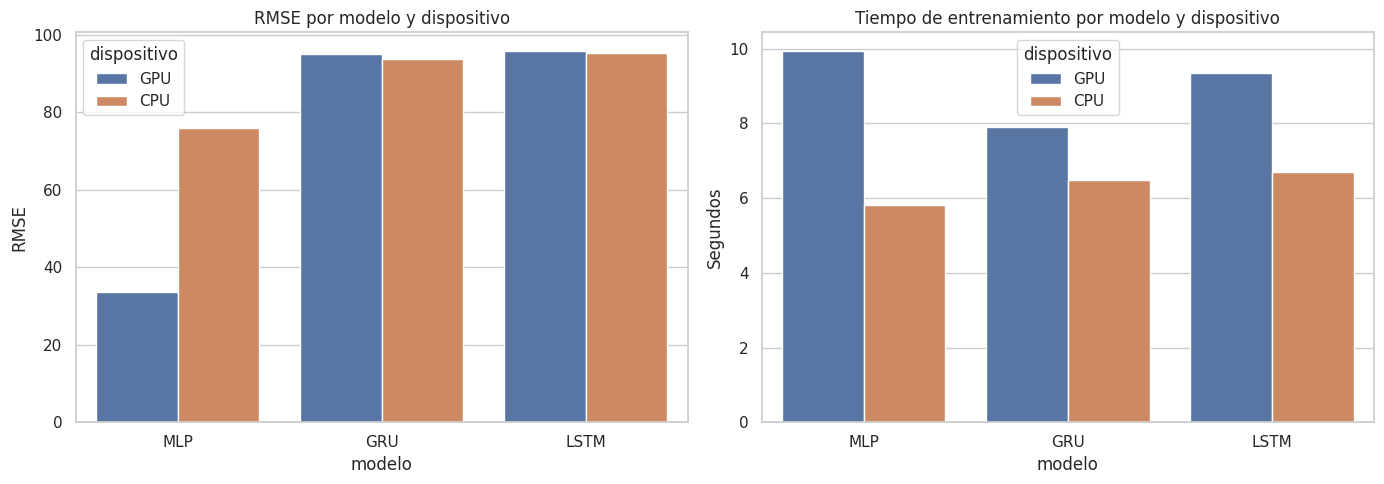

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=tabla_resultados, x="modelo", y="RMSE", hue="dispositivo", ax=axes[0])
axes[0].set_title("RMSE por modelo y dispositivo")
axes[0].set_ylabel("RMSE")

sns.barplot(data=tabla_resultados, x="modelo", y="tiempo_entrenamiento_seg", hue="dispositivo", ax=axes[1])
axes[1].set_title("Tiempo de entrenamiento por modelo y dispositivo")
axes[1].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

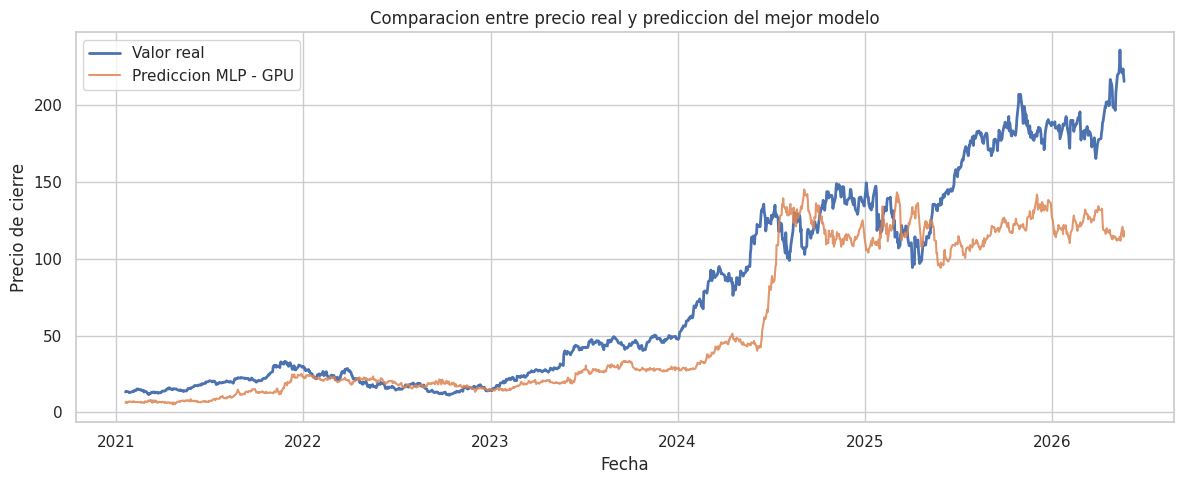

In [18]:
mejor_fila = tabla_resultados.iloc[0]
mejor_clave = (mejor_fila["dispositivo"], mejor_fila["modelo"])

fechas_prueba = test_df["date"].iloc[WINDOW_SIZE:].reset_index(drop=True)
y_test_real = target_scaler.inverse_transform(y_test)
predicciones_mejor_modelo = artefactos[mejor_clave]["predicciones"]

plt.figure(figsize=(12, 5))
plt.plot(fechas_prueba, y_test_real, label="Valor real", linewidth=2)
plt.plot(fechas_prueba, predicciones_mejor_modelo, label=f"Prediccion {mejor_fila['modelo']} - {mejor_fila['dispositivo']}", alpha=0.85)
plt.title("Comparacion entre precio real y prediccion del mejor modelo")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Conclusion automatica

In [19]:
mejor = tabla_resultados.iloc[0]

print("Mejor combinacion encontrada")
print("-----------------------------")
print(f"Modelo: {mejor['modelo']}")
print(f"Dispositivo: {mejor['dispositivo']}")
print(f"RMSE: {mejor['RMSE']:.4f}")
print(f"MAE: {mejor['MAE']:.4f}")
print(f"MAPE: {mejor['MAPE_%']:.2f}%")
print(f"Tiempo de entrenamiento: {mejor['tiempo_entrenamiento_seg']:.2f} segundos")

if "GPU" in tabla_resultados["dispositivo"].values:
    tiempos_promedio = tabla_resultados.groupby("dispositivo")["tiempo_entrenamiento_seg"].mean()
    print("\nTiempo promedio por dispositivo:")
    print(tiempos_promedio)

Mejor combinacion encontrada
-----------------------------
Modelo: MLP
Dispositivo: GPU
RMSE: 33.7133
MAE: 23.7397
MAPE: 31.90%
Tiempo de entrenamiento: 9.94 segundos

Tiempo promedio por dispositivo:
dispositivo
CPU    6.330338
GPU    9.068406
Name: tiempo_entrenamiento_seg, dtype: float64


## 11. Conclusiones para el reporte

- Se realizo una lectura local del archivo `NVIDIA_Stock_Prices.csv`. El archivo contiene un encabezado informativo de MacroTrends, por lo que la tabla se cargo saltando las primeras 14 filas.
- En el analisis exploratorio se revisaron dimensiones, fechas, valores faltantes, estadisticas descriptivas, evolucion del precio de cierre, volumen, retornos diarios y correlaciones entre variables numericas.
- Para la prediccion se construyo una serie temporal supervisada: cada observacion utiliza una ventana de dias anteriores para predecir el precio de cierre del siguiente dia.
- Se entrenaron tres modelos con TensorFlow: una red densa `MLP`, una red recurrente `LSTM` y una red recurrente `GRU`.
- La comparacion CPU vs GPU se realiza usando el mismo dataset, la misma particion temporal, las mismas epocas y el mismo tamano de batch. La tabla `tabla_resultados` permite identificar el mejor modelo segun RMSE y comparar el tiempo de entrenamiento por dispositivo.
- El mejor algoritmo debe elegirse a partir del menor RMSE en prueba. Si dos modelos tienen errores similares, tambien conviene considerar el tiempo de entrenamiento y la simplicidad del modelo.